In [1]:
import re

import gensim
import gensim.corpora as corpora
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import spacy

from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [3]:
plt.rcParams["figure.figsize"] = (12, 8)
default_plot_color = "#00bfbf"

In [4]:
data = pd.read_csv("Files/fake_news_data.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


fake_or_factual
Factual News    100
Fake News        98
Name: count, dtype: int64


Text(0.5, 1.0, 'Count of article classification')

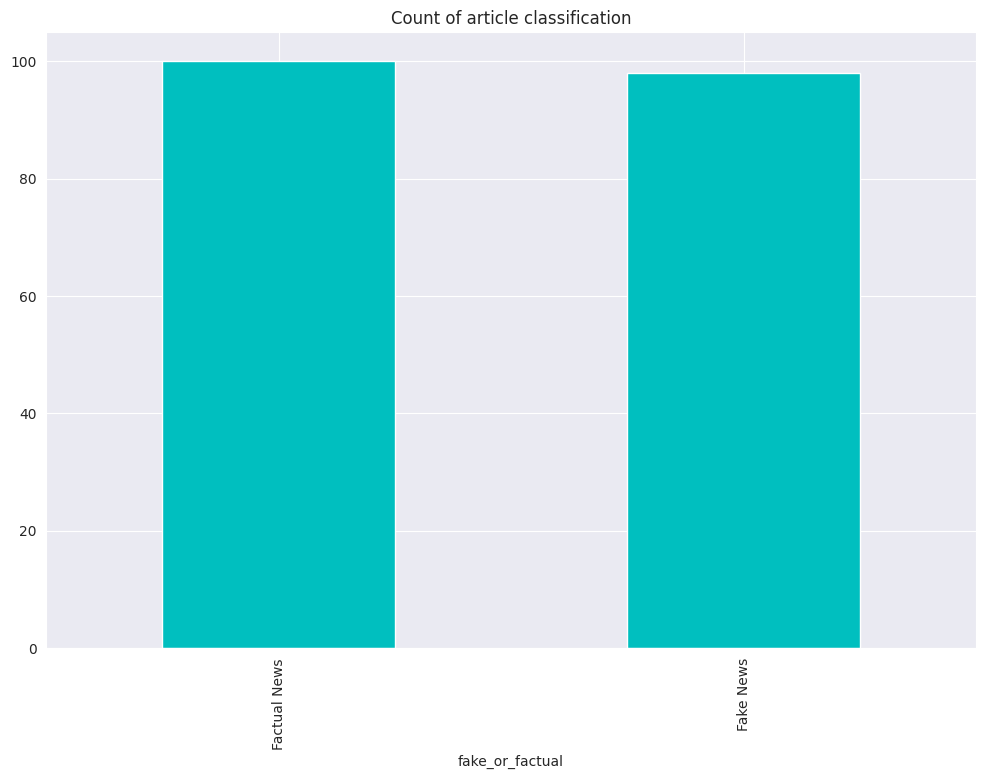

In [6]:
print(data.fake_or_factual.value_counts())
data.fake_or_factual.value_counts().plot(kind="bar", color=default_plot_color)
plt.title("Count of article classification")

### POS TAGGING

In [7]:
spacy.util.get_installed_models()

['en_core_web_sm']

In [8]:
nlp = spacy.load("en_core_web_sm")

In [24]:
fake_news = data[data.fake_or_factual == "Fake News"]
fake_spacy_docs = list(nlp.pipe(fake_news.text))
factual_news = data[data.fake_or_factual == "Factual News"]
fact_spacy_docs = list(nlp.pipe(factual_news.text))

In [28]:
factual_news.iloc[3].text
def extract_token_tags(doc: spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]

In [43]:
def loop_tags(spacy_docs):
    tags_df = []
    columns = ["token", "ner_tag", "pos_tag"]
    for idx, doc in enumerate(spacy_docs):
        tags = extract_token_tags(doc)
        tags = pd.DataFrame(tags)
        tags.columns = columns
        tags_df.append(tags)
    return pd.concat(tags_df)

In [47]:
fake_tags_df = loop_tags(fake_spacy_docs)
fact_tags_df = loop_tags(fact_spacy_docs)
fake_tags_df

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN
...,...,...,...
743,.,,PUNCT
744,Via,,PROPN
745,:,,PUNCT
746,Campus,PERSON,PROPN


In [76]:
print(fake_news.iloc[0].text[:70])
def pos_counts(tags_df):
    return tags_df.groupby(["token", "pos_tag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)
pos_counts_fake = pos_counts(fake_tags_df)
pos_counts_fact = pos_counts(fact_tags_df)
pos_counts_fact

There are two small problems with your analogy Susan  Jesus was NOT a 


,token,pos_tag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
...,...,...,...
2909,crossing,VERB,1
2911,crucial,ADJ,1
2913,cruise,NOUN,1
2914,crusade,NOUN,1
